# Эксперименты с Decision Transformer 

Сравним DT без памяти с DT+GRU и DT+LSTM и влияние на результат
- context_length
- размера датасета
- target_return (RTG при инференсе)




GitHub repo: 

In [1]:
import os
import json
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import Optional, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd()
if not (ROOT / "memory_dt.py").exists():
    ROOT = ROOT / "Decision-Transformer-with-Memory-for-POMDPs"
os.chdir(ROOT)

from pomdp_envs.velocity_cartpole import VelocityCartPoleEnv
from memory_dt import (
    MemoryDecisionTransformer,
    train_memory_dt,
    evaluate_memory_dt,
    POMDPDataset,
)

Для экспериментов возьму меньшее число эпох и степов эвала, чтобы быстрее всё прогнать

In [4]:
ENV_NAME = "velocity_cartpole"
DATASET_PATH = ROOT / "pomdp_datasets" / ENV_NAME
RESULTS_DIR = ROOT / "results"
MODELS_DIR = ROOT / "models"
RESULTS_CSV = RESULTS_DIR / "ablations.csv"

N_EPOCHS = 3
EVAL_EPISODES = 5
BATCH_SIZE = 64

# Гиперпараметры как в run_memory_dt.py
N_EMBED = 64
N_LAYER = 3
N_HEAD = 4
MEMORY_DIM = 64
DEFAULT_CONTEXT = 20
DEFAULT_TARGET_RTG = 500.0
SUCCESS_THRESHOLD = 450.0

MEMORY_TYPES = ["none", "gru", "lstm"]
QUICK_MODE = False  # True — укороченные сетки RTG в секции сравнения

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

In [10]:
@dataclass
class ExperimentResult:
    experiment: str
    memory_type: str
    context_length: int
    n_trajectories: Optional[int]
    target_return: float
    mean_return: float
    std_return: float
    success_rate: float
    model_path: str
    trained: bool


def mem_to_model_label(memory_type: str) -> str:
    return "none" if memory_type == "none" else memory_type


def default_checkpoint(memory_type: str) -> Path:
    """Чекпоинты базового прогона (без experiment_tag)."""
    label = mem_to_model_label(memory_type)
    return MODELS_DIR / f"memory_dt_{ENV_NAME}_{label}_best.pt"


def tagged_checkpoint(memory_type: str, experiment_tag: str) -> Path:
    label = mem_to_model_label(memory_type)
    return MODELS_DIR / f"memory_dt_{ENV_NAME}_{label}_{experiment_tag}_best.pt"


def create_env():
    return VelocityCartPoleEnv()


def build_model(memory_type: str, context_length: int = DEFAULT_CONTEXT):
    env = create_env()
    state_dim = env.observation_space.shape[0]
    n_actions = env.action_space.n
    env.close()
    mt = None if memory_type == "none" else memory_type
    model = MemoryDecisionTransformer(
        state_dim=state_dim,
        n_actions=n_actions,
        n_embed=N_EMBED,
        n_layer=N_LAYER,
        n_head=N_HEAD,
        context_length=context_length,
        memory_type=mt,
        memory_dim=MEMORY_DIM,
    )
    return model


def load_model_from_checkpoint(
    path: Path,
    memory_type: str,
    context_length: int = DEFAULT_CONTEXT,
):
    model = build_model(memory_type, context_length)
    state = torch.load(path, weights_only=True)
    model.load_state_dict(state)
    model
    model.eval()
    return model


def run_evaluation(
    model,
    context_length: int,
    target_return: float,
    num_episodes: int = EVAL_EPISODES,
):
    env = create_env()
    mean_return, returns, success_rate = evaluate_memory_dt(
        model=model,
        env=env,
        num_episodes=num_episodes,
        target_return=target_return,
        context_length=context_length,
        render=False,
    )
    env.close()
    return float(mean_return), float(np.std(returns)), float(success_rate)


def train_and_evaluate(
    memory_type: str,
    context_length: int,
    n_trajectories: Optional[int] = None,
    experiment_tag: Optional[str] = None,
    target_return: float = DEFAULT_TARGET_RTG,
):
    mt = None if memory_type == "none" else memory_type
    _, _, val_returns, ckpt_path = train_memory_dt(
        env_name=ENV_NAME,
        dataset_path=str(DATASET_PATH),
        n_epochs=N_EPOCHS,
        batch_size=BATCH_SIZE,
        context_length=context_length,
        n_embed=N_EMBED,
        n_layer=N_LAYER,
        n_head=N_HEAD,
        memory_type=mt,
        memory_dim=MEMORY_DIM,
        learning_rate=1e-3,
        weight_decay=1e-4,
        max_trajectories=n_trajectories,
        experiment_tag=experiment_tag,
        save_plots=True,
    )
    model = load_model_from_checkpoint(Path(ckpt_path), memory_type, context_length)
    mean_r, std_r, sr = run_evaluation(model, context_length, target_return)
    return model, mean_r, std_r, sr, ckpt_path, val_returns


def append_results(rows: List[ExperimentResult], deduplicate: bool = True):
    """Добавляет строки в CSV; при deduplicate заменяет совпадающие эксперименты."""
    df_new = pd.DataFrame([asdict(r) for r in rows])
    key_cols = [
        "experiment", "memory_type", "context_length",
        "n_trajectories", "target_return",
    ]
    if RESULTS_CSV.exists():
        df_old = pd.read_csv(RESULTS_CSV)
        df = pd.concat([df_old, df_new], ignore_index=True)
    else:
        df = df_new
    if deduplicate and not df.empty:
        df = df.drop_duplicates(subset=key_cols, keep="last")
    df.to_csv(RESULTS_CSV, index=False)
    return df


def load_all_results() -> pd.DataFrame:
    if RESULTS_CSV.exists():
        return pd.read_csv(RESULTS_CSV)
    return pd.DataFrame()


def plot_metric(df, x_col, y_col="mean_return", hue="memory_type", title=""):
    if df.empty:
        print("No data to plot")
        return
    fig, ax = plt.subplots(figsize=(8, 4))
    for mem, g in df.groupby(hue):
        g = g.sort_values(x_col)
        ax.plot(g[x_col], g[y_col], marker="o", label=mem)
        ax.fill_between(
            g[x_col],
            g[y_col] - g.get("std_return", 0),
            g[y_col] + g.get("std_return", 0),
            alpha=0.15,
        )
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(title or y_col)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def get_ema_alpha_stats(model):
    if not hasattr(model, "decay"):
        return None
    alpha = torch.sigmoid(model.decay).detach().cpu()
    return {
        "mean": float(alpha.mean()),
        "min": float(alpha.min()),
        "max": float(alpha.max()),
        "values": alpha.numpy(),
    }

### Базовое сравнение, как из README

Оценивает уже обученные моделт при дефолтных настройках.

In [16]:
baseline_rows = []

for mem in MEMORY_TYPES:
    ckpt = default_checkpoint(mem)
    if not ckpt.exists():
        print(f"Skip {mem}: нет файла {ckpt}")
        continue
    print(f"Eval {mem} <- {ckpt.name}")
    model = load_model_from_checkpoint(ckpt, mem, DEFAULT_CONTEXT)
    mean_r, std_r, sr = run_evaluation(model, DEFAULT_CONTEXT, DEFAULT_TARGET_RTG)
    print(f"  mean_return={mean_r:.1f}, success_rate={sr:.1%}")
    baseline_rows.append(
        ExperimentResult(
            experiment="baseline",
            memory_type=mem,
            context_length=DEFAULT_CONTEXT,
            n_trajectories=None,
            target_return=DEFAULT_TARGET_RTG,
            mean_return=mean_r,
            std_return=std_r,
            success_rate=sr,
            model_path=str(ckpt),
            trained=False,
        )
    )

df_baseline = append_results(baseline_rows)
display(df_baseline[df_baseline["experiment"] == "baseline"].sort_values("memory_type"))

Eval none <- memory_dt_velocity_cartpole_none_best.pt
Episode 1: Return=65.0, Steps=65
Episode 2: Return=78.0, Steps=78
Episode 3: Return=16.0, Steps=16
Episode 4: Return=42.0, Steps=42
Episode 5: Return=284.0, Steps=284
Evaluation Summary:
Mean Return: 97.00
Success Rate: 0.00%
  mean_return=97.0, success_rate=0.0%
Eval gru <- memory_dt_velocity_cartpole_gru_best.pt
Episode 1: Return=500.0, Steps=500
Episode 2: Return=500.0, Steps=500
Episode 3: Return=500.0, Steps=500
Episode 4: Return=500.0, Steps=500
Episode 5: Return=500.0, Steps=500
Evaluation Summary:
Mean Return: 500.00
Success Rate: 100.00%
  mean_return=500.0, success_rate=100.0%
Eval lstm <- memory_dt_velocity_cartpole_lstm_best.pt
Episode 1: Return=500.0, Steps=500
Episode 2: Return=500.0, Steps=500
Episode 3: Return=500.0, Steps=500
Episode 4: Return=500.0, Steps=500
Episode 5: Return=500.0, Steps=500
Evaluation Summary:
Mean Return: 500.00
Success Rate: 100.00%
  mean_return=500.0, success_rate=100.0%


/var/folders/4h/ywyvmt4d4mbghw8hp9zl9b900000gp/T/ipykernel_20532/793929767.py:124: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df_old, df_new], ignore_index=True)


,experiment,memory_type,context_length,n_trajectories,target_return,mean_return,std_return,success_rate,model_path,trained
29,baseline,gru,20,NaN,500.0,500.0,0.000000,1.0,/Users/pevcov.artem2/Code/AIM/RL/Decision-Tran...,False
30,baseline,lstm,20,NaN,500.0,500.0,0.000000,1.0,/Users/pevcov.artem2/Code/AIM/RL/Decision-Tran...,False
28,baseline,none,20,NaN,500.0,97.0,95.854056,0.0,/Users/pevcov.artem2/Code/AIM/RL/Decision-Tran...,False


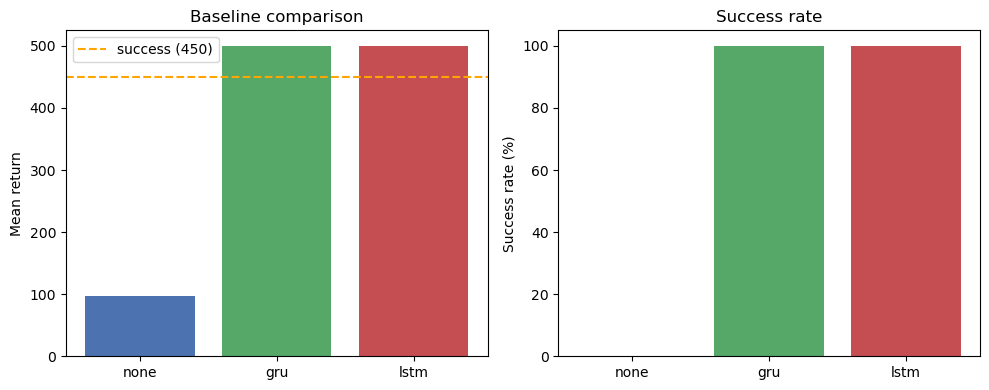

In [17]:
df_base = load_all_results()
df_base = df_base[df_base["experiment"] == "baseline"]
if not df_base.empty:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    colors = {"none": "#4C72B0", "gru": "#55A868", "lstm": "#C44E52"}
    x = np.arange(len(df_base))
    labels = df_base["memory_type"].tolist()
    axes[0].bar(x, df_base["mean_return"], color=[colors.get(m, "gray") for m in labels])
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels)
    axes[0].set_ylabel("Mean return")
    axes[0].set_title("Baseline comparison")
    axes[0].axhline(SUCCESS_THRESHOLD, color="orange", ls="--", label="success (450)")
    axes[0].legend()
    axes[1].bar(x, df_base["success_rate"] * 100, color=[colors.get(m, "gray") for m in labels])
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels)
    axes[1].set_ylabel("Success rate (%)")
    axes[1].set_title("Success rate")
    plt.tight_layout()
    plt.show()

Тут уже видно, что с GRU и LSTM модель рабюотает значительно лучше, но пока непонятно какая из них лучше, так как обучент показывает одинаковый 100% success rate

### Зависимость от Ablation: target return (RTG)

Только инференс, переобучение не нужно. Меняем target_return при оценке.

In [18]:
RTG_VALUES = [300, 400, 500, 600]

rtg_rows = []
for mem in MEMORY_TYPES:
    ckpt = default_checkpoint(mem)
    if not ckpt.exists():
        continue
    model = load_model_from_checkpoint(ckpt, mem, DEFAULT_CONTEXT)
    for rtg in RTG_VALUES:
        mean_r, std_r, sr = run_evaluation(model, DEFAULT_CONTEXT, rtg)
        print(f"{mem} @ RTG={rtg}: return={mean_r:.1f}, success={sr:.1%}")
        rtg_rows.append(
            ExperimentResult(
                experiment="rtg_sweep",
                memory_type=mem,
                context_length=DEFAULT_CONTEXT,
                n_trajectories=None,
                target_return=float(rtg),
                mean_return=mean_r,
                std_return=std_r,
                success_rate=sr,
                model_path=str(ckpt),
                trained=False,
            )
        )

df_all = append_results(rtg_rows)
df_rtg = df_all[df_all["experiment"] == "rtg_sweep"]
display(df_rtg.pivot_table(index="target_return", columns="memory_type", values="mean_return"))

Episode 1: Return=100.0, Steps=100
Episode 2: Return=314.0, Steps=314
Episode 3: Return=98.0, Steps=98
Episode 4: Return=311.0, Steps=311
Episode 5: Return=66.0, Steps=66
Evaluation Summary:
Mean Return: 177.80
Success Rate: 0.00%
none @ RTG=300: return=177.8, success=0.0%
Episode 1: Return=20.0, Steps=20
Episode 2: Return=391.0, Steps=391
Episode 3: Return=169.0, Steps=169
Episode 4: Return=20.0, Steps=20
Episode 5: Return=142.0, Steps=142
Evaluation Summary:
Mean Return: 148.40
Success Rate: 0.00%
none @ RTG=400: return=148.4, success=0.0%
Episode 1: Return=61.0, Steps=61
Episode 2: Return=80.0, Steps=80
Episode 3: Return=92.0, Steps=92
Episode 4: Return=149.0, Steps=149
Episode 5: Return=120.0, Steps=120
Evaluation Summary:
Mean Return: 100.40
Success Rate: 0.00%
none @ RTG=500: return=100.4, success=0.0%
Episode 1: Return=104.0, Steps=104
Episode 2: Return=20.0, Steps=20
Episode 3: Return=74.0, Steps=74
Episode 4: Return=16.0, Steps=16
Episode 5: Return=32.0, Steps=32
Evaluation Su

/var/folders/4h/ywyvmt4d4mbghw8hp9zl9b900000gp/T/ipykernel_20532/793929767.py:124: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df_old, df_new], ignore_index=True)


memory_type,gru,lstm,none
target_return,,,
300.0,500.0,305.4,177.8
400.0,500.0,407.4,148.4
500.0,500.0,500.0,100.4
600.0,500.0,500.0,49.2


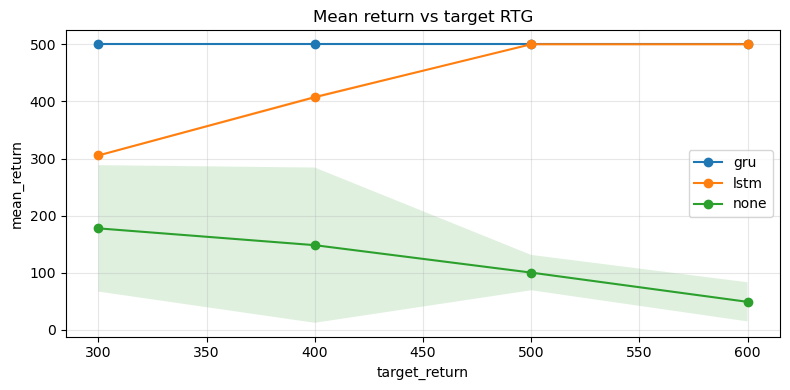

In [19]:
plot_metric(
    df_rtg,
    x_col="target_return",
    title="Mean return vs target RTG",
)

Инетресно, что получилось, что модель без памяти полказывается себя лучше при меньшем target_return, а с lstm выдает в среднем сколько просят)) 

### Зависимость от context length

In [23]:
CONTEXT_VALUES = [5, 10, 20]

ctx_rows = []
for ctx in CONTEXT_VALUES:
    for mem in MEMORY_TYPES:
        tag = f"ctx{ctx}"
        ckpt = tagged_checkpoint(mem, tag)
        trained = False
        model = load_model_from_checkpoint(ckpt, mem, ctx)
        mean_r, std_r, sr = run_evaluation(model, ctx, DEFAULT_TARGET_RTG)

        print(f"  {mem} ctx={ctx}: return={mean_r:.1f}")
        ctx_rows.append(
            ExperimentResult(
                experiment="context_sweep",
                memory_type=mem,
                context_length=ctx,
                n_trajectories=None,
                target_return=DEFAULT_TARGET_RTG,
                mean_return=mean_r,
                std_return=std_r,
                success_rate=sr,
                model_path=str(ckpt),
                trained=trained,
            )
        )

df_all = append_results(ctx_rows)
df_ctx = df_all[df_all["experiment"] == "context_sweep"]
display(df_ctx.pivot_table(index="context_length", columns="memory_type", values="mean_return"))

Episode 1: Return=59.0, Steps=59
Episode 2: Return=33.0, Steps=33
Episode 3: Return=72.0, Steps=72
Episode 4: Return=55.0, Steps=55
Episode 5: Return=116.0, Steps=116
Evaluation Summary:
Mean Return: 67.00
Success Rate: 0.00%
  none ctx=5: return=67.0
Episode 1: Return=500.0, Steps=500
Episode 2: Return=500.0, Steps=500
Episode 3: Return=500.0, Steps=500
Episode 4: Return=500.0, Steps=500
Episode 5: Return=500.0, Steps=500
Evaluation Summary:
Mean Return: 500.00
Success Rate: 100.00%
  gru ctx=5: return=500.0
Episode 1: Return=500.0, Steps=500
Episode 2: Return=500.0, Steps=500
Episode 3: Return=500.0, Steps=500
Episode 4: Return=500.0, Steps=500
Episode 5: Return=500.0, Steps=500
Evaluation Summary:
Mean Return: 500.00
Success Rate: 100.00%
  lstm ctx=5: return=500.0
Episode 1: Return=205.0, Steps=205
Episode 2: Return=500.0, Steps=500
Episode 3: Return=500.0, Steps=500
Episode 4: Return=500.0, Steps=500
Episode 5: Return=283.0, Steps=283
Evaluation Summary:
Mean Return: 397.60
Succes

/var/folders/4h/ywyvmt4d4mbghw8hp9zl9b900000gp/T/ipykernel_20532/793929767.py:124: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df_old, df_new], ignore_index=True)


memory_type,gru,lstm,none
context_length,,,
5,500.0,500.0,67.0
10,500.0,500.0,397.6
20,500.0,500.0,500.0


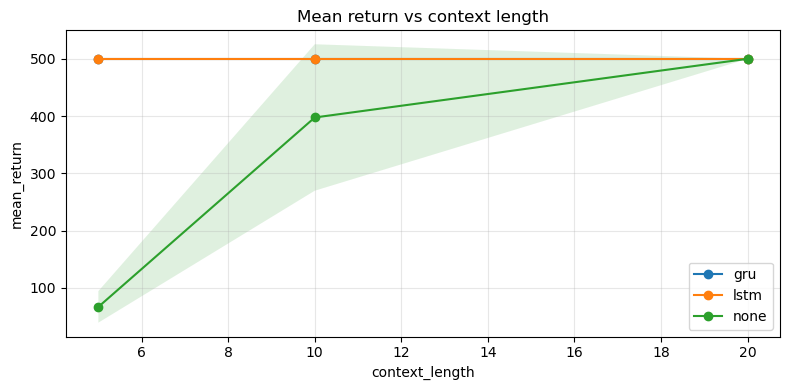

In [24]:
plot_metric(df_ctx, x_col="context_length", title="Mean return vs context length")

Получается увеличением контекста можно добить модель без памяти до хорошего реварда, а вот gru и lstm работают хорошо даже с маленьким контекстом

### Зависимость от размера датасета

Использует первые N файлов train_data_*.npz.

In [27]:
DATASET_SIZES = [25, 50] 

data_rows = []
for n_traj in DATASET_SIZES:
    for mem in MEMORY_TYPES:
        tag = f"n{n_traj}"
        ckpt = tagged_checkpoint(mem, tag)
        trained = False

        model = load_model_from_checkpoint(ckpt, mem, DEFAULT_CONTEXT)
        mean_r, std_r, sr = run_evaluation(model, DEFAULT_CONTEXT, DEFAULT_TARGET_RTG)

        print(f"  {mem} N={n_traj}: return={mean_r:.1f}")
        data_rows.append(
            ExperimentResult(
                experiment="dataset_sweep",
                memory_type=mem,
                context_length=DEFAULT_CONTEXT,
                n_trajectories=n_traj,
                target_return=DEFAULT_TARGET_RTG,
                mean_return=mean_r,
                std_return=std_r,
                success_rate=sr,
                model_path=str(ckpt),
                trained=trained,
            )
        )

df_all = append_results(data_rows)
df_data = df_all[df_all["experiment"] == "dataset_sweep"]
display(df_data.pivot_table(index="n_trajectories", columns="memory_type", values="mean_return"))

Episode 1: Return=30.0, Steps=30
Episode 2: Return=28.0, Steps=28
Episode 3: Return=29.0, Steps=29
Episode 4: Return=31.0, Steps=31
Episode 5: Return=15.0, Steps=15
Evaluation Summary:
Mean Return: 26.60
Success Rate: 0.00%
  none N=25: return=26.6
Episode 1: Return=271.0, Steps=271
Episode 2: Return=487.0, Steps=487
Episode 3: Return=497.0, Steps=497
Episode 4: Return=500.0, Steps=500
Episode 5: Return=500.0, Steps=500
Evaluation Summary:
Mean Return: 451.00
Success Rate: 80.00%
  gru N=25: return=451.0
Episode 1: Return=500.0, Steps=500
Episode 2: Return=500.0, Steps=500
Episode 3: Return=500.0, Steps=500
Episode 4: Return=500.0, Steps=500
Episode 5: Return=500.0, Steps=500
Evaluation Summary:
Mean Return: 500.00
Success Rate: 100.00%
  lstm N=25: return=500.0
Episode 1: Return=500.0, Steps=500
Episode 2: Return=500.0, Steps=500
Episode 3: Return=500.0, Steps=500
Episode 4: Return=500.0, Steps=500
Episode 5: Return=500.0, Steps=500
Evaluation Summary:
Mean Return: 500.00
Success Rate

memory_type,gru,lstm,none
n_trajectories,,,
25.0,451.0,500.0,26.6
50.0,500.0,500.0,500.0


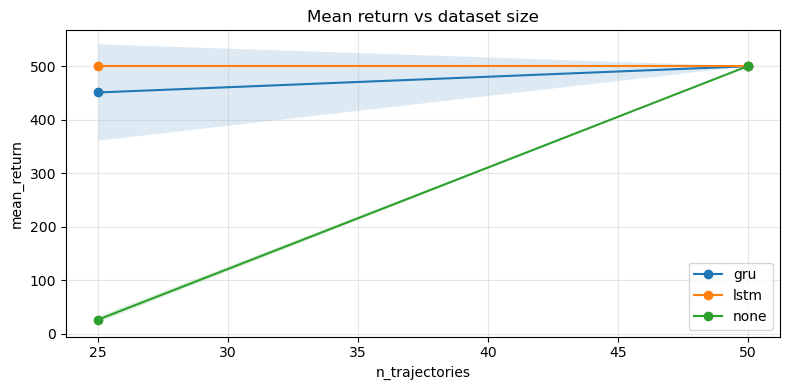

In [28]:
plot_metric(df_data, x_col="n_trajectories", title="Mean return vs dataset size")

Тут всё логично, интересно, что lstm быстрее сошелся

## Свой подход памяти.

Кажется, что задача достаточно простая и можно прикрутить механизм памяти полегче, чем LSTM и GRU

На каждом шаге обновляем экспоненциальное среднее эмбеддингов состояний:

$$
\text{ema}_t = \alpha \odot \text{ema}_{t-1} + (1 - \alpha) \odot \text{embed}(o_t)
$$

где $\alpha = \sigma(\text{decay})$ это обучаемый поканальный вектор (свой коэффициент сохранения для каждого измерения эмбеддинга)


In [11]:
CUSTOM_MEMORY = "ema"
COMPARE_TYPES = ["none", "gru", "lstm", "ema"]
COLORS = {"none": "#4C72B0", "gru": "#55A868", "lstm": "#C44E52", "ema": "#8172B2"}
RUN_TRAINING = True

ema_ckpt = default_checkpoint(CUSTOM_MEMORY)
training_history = {}

if RUN_TRAINING or not ema_ckpt.exists():
    print(f"Training DT+{CUSTOM_MEMORY.upper()}...")
    model_ema, train_losses, val_returns, ckpt_path = train_memory_dt(
        env_name=ENV_NAME,
        dataset_path=str(DATASET_PATH),
        n_epochs=N_EPOCHS,
        batch_size=BATCH_SIZE,
        context_length=DEFAULT_CONTEXT,
        n_embed=N_EMBED,
        n_layer=N_LAYER,
        n_head=N_HEAD,
        memory_type=CUSTOM_MEMORY,
        memory_dim=MEMORY_DIM,
        learning_rate=1e-3,
        weight_decay=1e-4,
        experiment_tag=None,
        save_plots=True,
    )
    ema_ckpt = Path(ckpt_path)
    training_history[CUSTOM_MEMORY] = {
        "train_losses": train_losses,
        "val_returns": val_returns,
    }
else:
    print(f"Using existing checkpoint: {ema_ckpt}")

# Eval EMA
model_ema = load_model_from_checkpoint(ema_ckpt, CUSTOM_MEMORY, DEFAULT_CONTEXT)
ema_mean, ema_std, ema_sr = run_evaluation(model_ema, DEFAULT_CONTEXT, DEFAULT_TARGET_RTG)
alpha_stats = get_ema_alpha_stats(model_ema)
print(
    f"EMA eval: return={ema_mean:.1f} ± {ema_std:.1f}, success={ema_sr:.1%}, "
    f"α mean={alpha_stats['mean']:.3f} (min={alpha_stats['min']:.3f}, max={alpha_stats['max']:.3f})"
)

append_results([
    ExperimentResult(
        experiment="custom_ema",
        memory_type=CUSTOM_MEMORY,
        context_length=DEFAULT_CONTEXT,
        n_trajectories=None,
        target_return=DEFAULT_TARGET_RTG,
        mean_return=ema_mean,
        std_return=ema_std,
        success_rate=ema_sr,
        model_path=str(ema_ckpt),
        trained=RUN_TRAINING,
    )
])

Training DT+EMA...
Dataset stats: total=49882, train=44893, val=4989, state_dim=2, actions=2


Epoch 1/3 [Train]: 100%|██████████| 702/702 [00:52<00:00, 13.42it/s, loss=0.3938, avg_loss=0.4784, lr=0.000843]


Epoch 1/3: Train Loss=0.4784, Val Loss=0.3974
Running environment validation...
Episode 1: Return=500.0, Steps=500
Episode 2: Return=500.0, Steps=500
Episode 3: Return=15.0, Steps=15
Episode 4: Return=500.0, Steps=500
Episode 5: Return=500.0, Steps=500
Episode 6: Return=500.0, Steps=500
Episode 7: Return=12.0, Steps=12
Episode 8: Return=14.0, Steps=14
Episode 9: Return=500.0, Steps=500
Episode 10: Return=12.0, Steps=12
Validation: Mean Return=305.30, Success Rate=60.00%
New best model with return 305.30


Epoch 2/3 [Train]: 100%|██████████| 702/702 [00:46<00:00, 15.18it/s, loss=0.4273, avg_loss=0.3947, lr=0.000302]


Epoch 2/3: Train Loss=0.3947, Val Loss=0.3811
Running environment validation...
Episode 1: Return=500.0, Steps=500
Episode 2: Return=15.0, Steps=15
Episode 3: Return=500.0, Steps=500
Episode 4: Return=12.0, Steps=12
Episode 5: Return=14.0, Steps=14
Episode 6: Return=13.0, Steps=13
Episode 7: Return=15.0, Steps=15
Episode 8: Return=500.0, Steps=500
Episode 9: Return=500.0, Steps=500
Episode 10: Return=500.0, Steps=500
Validation: Mean Return=256.90, Success Rate=50.00%


Epoch 3/3 [Train]: 100%|██████████| 702/702 [00:51<00:00, 13.57it/s, loss=0.3974, avg_loss=0.3811, lr=0.000000]


Epoch 3/3: Train Loss=0.3811, Val Loss=0.3722
Running environment validation...
Episode 1: Return=11.0, Steps=11
Episode 2: Return=13.0, Steps=13
Episode 3: Return=12.0, Steps=12
Episode 4: Return=11.0, Steps=11
Episode 5: Return=13.0, Steps=13
Episode 6: Return=500.0, Steps=500
Episode 7: Return=15.0, Steps=15
Episode 8: Return=12.0, Steps=12
Episode 9: Return=500.0, Steps=500
Episode 10: Return=11.0, Steps=11
Validation: Mean Return=109.80, Success Rate=20.00%
Best model saved to models/memory_dt_velocity_cartpole_ema_best.pt
Episode 1: Return=13.0, Steps=13
Episode 2: Return=15.0, Steps=15
Episode 3: Return=500.0, Steps=500
Episode 4: Return=14.0, Steps=14
Episode 5: Return=500.0, Steps=500
Evaluation Summary:
Mean Return: 208.40
Success Rate: 40.00%
EMA eval: return=208.4 ± 238.1, success=40.0%, α mean=0.863 (min=0.591, max=0.976)


/var/folders/4h/ywyvmt4d4mbghw8hp9zl9b900000gp/T/ipykernel_25884/34000014.py:124: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df_old, df_new], ignore_index=True)


,experiment,memory_type,context_length,n_trajectories,target_return,mean_return,std_return,success_rate,model_path,trained
0,baseline,none,20,NaN,500.0,97.0,95.854056,0.0,/Users/pevcov.artem2/Code/AIM/RL/Decision-Tran...,False
1,baseline,gru,20,NaN,500.0,500.0,0.000000,1.0,/Users/pevcov.artem2/Code/AIM/RL/Decision-Tran...,False
2,baseline,lstm,20,NaN,500.0,500.0,0.000000,1.0,/Users/pevcov.artem2/Code/AIM/RL/Decision-Tran...,False
3,rtg_sweep,none,20,NaN,300.0,177.8,110.646103,0.0,/Users/pevcov.artem2/Code/AIM/RL/Decision-Tran...,False
4,rtg_sweep,none,20,NaN,400.0,148.4,135.862578,0.0,/Users/pevcov.artem2/Code/AIM/RL/Decision-Tran...,False
5,rtg_sweep,none,20,NaN,500.0,100.4,30.936063,0.0,/Users/pevcov.artem2/Code/AIM/RL/Decision-Tran...,False
6,rtg_sweep,none,20,NaN,600.0,49.2,34.260181,0.0,/Users/pevcov.artem2/Code/AIM/RL/Decision-Tran...,False
7,rtg_sweep,gru,20,NaN,300.0,500.0,0.000000,1.0,/Users/pevcov.artem2/Code/AIM/RL/Decision-Tran...,False
8,rtg_sweep,gru,20,NaN,400.0,500.0,0.000000,1.0,/Users/pevcov.artem2/Code/AIM/RL/Decision-Tran...,False
9,rtg_sweep,gru,20,NaN,500.0,500.0,0.000000,1.0,/Users/pevcov.artem2/Code/AIM/RL/Decision-Tran...,False


Episode 1: Return=91.0, Steps=91
Episode 2: Return=80.0, Steps=80
Episode 3: Return=56.0, Steps=56
Episode 4: Return=48.0, Steps=48
Episode 5: Return=155.0, Steps=155
Evaluation Summary:
Mean Return: 86.00
Success Rate: 0.00%
Episode 1: Return=500.0, Steps=500
Episode 2: Return=500.0, Steps=500
Episode 3: Return=500.0, Steps=500
Episode 4: Return=500.0, Steps=500
Episode 5: Return=500.0, Steps=500
Evaluation Summary:
Mean Return: 500.00
Success Rate: 100.00%
Episode 1: Return=500.0, Steps=500
Episode 2: Return=500.0, Steps=500
Episode 3: Return=500.0, Steps=500
Episode 4: Return=500.0, Steps=500
Episode 5: Return=500.0, Steps=500
Evaluation Summary:
Mean Return: 500.00
Success Rate: 100.00%
Episode 1: Return=12.0, Steps=12
Episode 2: Return=500.0, Steps=500
Episode 3: Return=12.0, Steps=12
Episode 4: Return=500.0, Steps=500
Episode 5: Return=500.0, Steps=500
Evaluation Summary:
Mean Return: 304.80
Success Rate: 60.00%


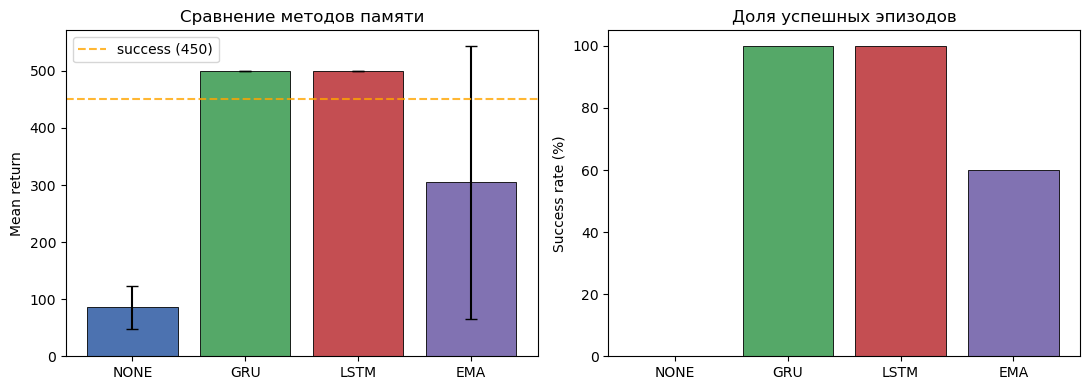

,memory_type,mean_return,std_return,success_rate
0,none,86.0,37.857628,0.0
1,gru,500.0,0.000000,1.0
2,lstm,500.0,0.000000,1.0
3,ema,304.8,239.070199,0.6


In [ ]:
comparison_rows = []
for mem in COMPARE_TYPES:
    ckpt = default_checkpoint(mem)
    if not ckpt.exists():
        continue
    model = load_model_from_checkpoint(ckpt, mem, DEFAULT_CONTEXT)
    mean_r, std_r, sr = run_evaluation(model, DEFAULT_CONTEXT, DEFAULT_TARGET_RTG)
    comparison_rows.append({"memory_type": mem, "mean_return": mean_r, "std_return": std_r, "success_rate": sr})

df_cmp = pd.DataFrame(comparison_rows)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
x = np.arange(len(df_cmp))
labels = df_cmp["memory_type"].tolist()

axes[0].bar(x, df_cmp["mean_return"], yerr=df_cmp["std_return"], capsize=4,
            color=[COLORS[m] for m in labels], edgecolor="black", linewidth=0.6)
axes[0].set_xticks(x)
axes[0].set_xticklabels([m.upper() for m in labels])
axes[0].set_ylabel("Mean return")
axes[0].set_title("Сравнение методов памяти")
axes[0].axhline(SUCCESS_THRESHOLD, color="orange", ls="--", alpha=0.8, label="success (450)")
axes[0].legend()

axes[1].bar(x, df_cmp["success_rate"] * 100, color=[COLORS[m] for m in labels], edgecolor="black", linewidth=0.6)
axes[1].set_xticks(x)
axes[1].set_xticklabels([m.upper() for m in labels])
axes[1].set_ylabel("Success rate (%)")
axes[1].set_title("Доля успешных эпизодов")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "custom_memory_comparison.png", dpi=150)
plt.show()
df_cmp

### EMA: зависимость от RTG и длины контекста

- **RTG** — только инференс с обученным чекпоинтом `ema` (context=20).
- **Context length** — отдельные модели `ema_ctx5/10/20` (переобучение при `RUN_EMA_CTX_TRAINING=True` или если чекпоинта нет).

На графиках EMA выделена жирной линией; none/GRU/LSTM — из основных аблаций (`rtg_sweep`, `context_sweep`).

Episode 1: Return=314.0, Steps=314
Episode 2: Return=12.0, Steps=12
Episode 3: Return=11.0, Steps=11
Episode 4: Return=11.0, Steps=11
Episode 5: Return=13.0, Steps=13
Evaluation Summary:
Mean Return: 72.20
Success Rate: 0.00%
EMA @ RTG=300: return=72.2 ± 120.9, success=0.0%
Episode 1: Return=11.0, Steps=11
Episode 2: Return=408.0, Steps=408
Episode 3: Return=408.0, Steps=408
Episode 4: Return=11.0, Steps=11
Episode 5: Return=11.0, Steps=11
Evaluation Summary:
Mean Return: 169.80
Success Rate: 0.00%
EMA @ RTG=400: return=169.8 ± 194.5, success=0.0%
Episode 1: Return=500.0, Steps=500
Episode 2: Return=500.0, Steps=500
Episode 3: Return=11.0, Steps=11
Episode 4: Return=500.0, Steps=500
Episode 5: Return=500.0, Steps=500
Evaluation Summary:
Mean Return: 402.20
Success Rate: 80.00%
EMA @ RTG=500: return=402.2 ± 195.6, success=80.0%
Episode 1: Return=15.0, Steps=15
Episode 2: Return=500.0, Steps=500
Episode 3: Return=16.0, Steps=16
Episode 4: Return=11.0, Steps=11
Episode 5: Return=13.0, Ste

/var/folders/4h/ywyvmt4d4mbghw8hp9zl9b900000gp/T/ipykernel_25884/34000014.py:124: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df_old, df_new], ignore_index=True)


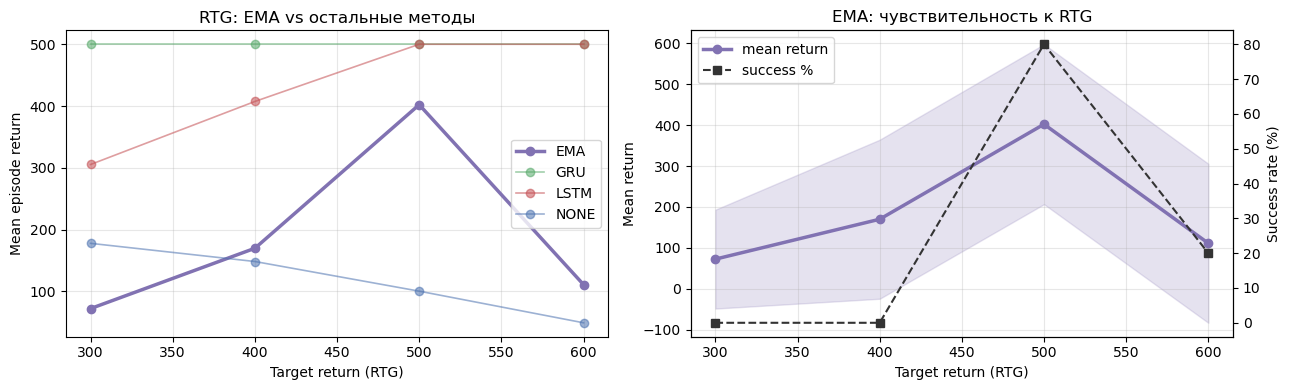

,mean_return,success_rate
target_return,,
300.0,72.2,0.0
400.0,169.8,0.0
500.0,402.2,0.8
600.0,111.0,0.2


In [16]:
# --- EMA: sweep по RTG ---
EMA_RTG_VALUES = [300, 400, 500, 600] 

ema_rtg_rows = []
model_ema_rtg = load_model_from_checkpoint(ema_ckpt, CUSTOM_MEMORY, DEFAULT_CONTEXT)
for rtg in EMA_RTG_VALUES:
    mean_r, std_r, sr = run_evaluation(model_ema_rtg, DEFAULT_CONTEXT, float(rtg))
    print(f"EMA @ RTG={rtg}: return={mean_r:.1f} ± {std_r:.1f}, success={sr:.1%}")
    ema_rtg_rows.append(
        ExperimentResult(
            experiment="ema_rtg_sweep",
            memory_type=CUSTOM_MEMORY,
            context_length=DEFAULT_CONTEXT,
            n_trajectories=None,
            target_return=float(rtg),
            mean_return=mean_r,
            std_return=std_r,
            success_rate=sr,
            model_path=str(ema_ckpt),
            trained=False,
        )
    )

df_all = append_results(ema_rtg_rows)
df_ema_rtg = df_all[df_all["experiment"] == "ema_rtg_sweep"]

df_rtg_base = load_all_results()
df_rtg_base = df_rtg_base[df_rtg_base["experiment"] == "rtg_sweep"]
if df_rtg_base.empty:
    print("Подсказка: запустите секцию «Ablation: target return», чтобы на левом графике были none/GRU/LSTM.")
df_rtg_overlay = pd.concat([df_rtg_base, df_ema_rtg], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for mem, g in df_rtg_overlay.groupby("memory_type"):
    g = g.sort_values("target_return")
    lw = 2.5 if mem == "ema" else 1.2
    alpha = 1.0 if mem == "ema" else 0.55
    ax.plot(
        g["target_return"],
        g["mean_return"],
        marker="o",
        label=mem.upper(),
        color=COLORS.get(mem),
        linewidth=lw,
        alpha=alpha,
    )
ax.set_xlabel("Target return (RTG)")
ax.set_ylabel("Mean episode return")
ax.set_title("RTG: EMA vs остальные методы")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
g = df_ema_rtg.sort_values("target_return")
ax.plot(
    g["target_return"],
    g["mean_return"],
    marker="o",
    color=COLORS["ema"],
    linewidth=2.5,
    label="mean return",
)
ax.fill_between(
    g["target_return"],
    g["mean_return"] - g["std_return"],
    g["mean_return"] + g["std_return"],
    alpha=0.2,
    color=COLORS["ema"],
)
ax2 = ax.twinx()
ax2.plot(
    g["target_return"],
    g["success_rate"] * 100,
    marker="s",
    color="#333",
    ls="--",
    label="success %",
)
ax.set_xlabel("Target return (RTG)")
ax.set_ylabel("Mean return")
ax2.set_ylabel("Success rate (%)")
ax.set_title("EMA: чувствительность к RTG")
lines1, labs1 = ax.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labs1 + labs2, loc="best")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "ema_rtg_comparison.png", dpi=150)
plt.show()

display(
    df_ema_rtg.pivot_table(
        index="target_return", values=["mean_return", "success_rate"]
    )
)

Training EMA, context_length=5...
Dataset stats: total=49927, train=44934, val=4993, state_dim=2, actions=2


Epoch 1/3 [Train]: 100%|██████████| 703/703 [00:18<00:00, 38.05it/s, loss=0.3958, avg_loss=0.5260, lr=0.000843]


Epoch 1/3: Train Loss=0.5260, Val Loss=0.4324
Running environment validation...
Episode 1: Return=107.0, Steps=107
Episode 2: Return=192.0, Steps=192
Episode 3: Return=72.0, Steps=72
Episode 4: Return=225.0, Steps=225
Episode 5: Return=107.0, Steps=107
Episode 6: Return=206.0, Steps=206
Episode 7: Return=130.0, Steps=130
Episode 8: Return=133.0, Steps=133
Episode 9: Return=363.0, Steps=363
Episode 10: Return=193.0, Steps=193
Validation: Mean Return=172.80, Success Rate=0.00%
New best model with return 172.80


Epoch 2/3 [Train]: 100%|██████████| 703/703 [00:17<00:00, 39.76it/s, loss=0.3275, avg_loss=0.4331, lr=0.000302]


Epoch 2/3: Train Loss=0.4331, Val Loss=0.4277
Running environment validation...
Episode 1: Return=500.0, Steps=500
Episode 2: Return=500.0, Steps=500
Episode 3: Return=500.0, Steps=500
Episode 4: Return=500.0, Steps=500
Episode 5: Return=500.0, Steps=500
Episode 6: Return=500.0, Steps=500
Episode 7: Return=500.0, Steps=500
Episode 8: Return=500.0, Steps=500
Episode 9: Return=500.0, Steps=500
Episode 10: Return=500.0, Steps=500
Validation: Mean Return=500.00, Success Rate=100.00%
New best model with return 500.00


...

Epoch 2/3 [Train]: 100%|██████████| 702/702 [00:44<00:00, 15.73it/s, loss=0.3917, avg_loss=0.3982, lr=0.000302]


Epoch 2/3: Train Loss=0.3982, Val Loss=0.3931
Running environment validation...
Episode 1: Return=9.0, Steps=9
Episode 2: Return=10.0, Steps=10
Episode 3: Return=8.0, Steps=8
Episode 4: Return=10.0, Steps=10
Episode 5: Return=8.0, Steps=8
Episode 6: Return=10.0, Steps=10
Episode 7: Return=9.0, Steps=9
Episode 8: Return=8.0, Steps=8
Episode 9: Return=10.0, Steps=10
Episode 10: Return=8.0, Steps=8
Validation: Mean Return=9.00, Success Rate=0.00%


Epoch 3/3 [Train]: 100%|██████████| 702/702 [00:45<00:00, 15.40it/s, loss=0.4044, avg_loss=0.3844, lr=0.000000]


Epoch 3/3: Train Loss=0.3844, Val Loss=0.3766
Running environment validation...
Episode 1: Return=9.0, Steps=9
Episode 2: Return=9.0, Steps=9
Episode 3: Return=9.0, Steps=9
Episode 4: Return=10.0, Steps=10
Episode 5: Return=10.0, Steps=10
Episode 6: Return=9.0, Steps=9
Episode 7: Return=9.0, Steps=9
Episode 8: Return=9.0, Steps=9
Episode 9: Return=9.0, Steps=9
Episode 10: Return=10.0, Steps=10
Validation: Mean Return=9.30, Success Rate=0.00%
Best model saved to models/memory_dt_velocity_cartpole_ema_ctx20_best.pt
Episode 1: Return=10.0, Steps=10
Episode 2: Return=9.0, Steps=9
Episode 3: Return=10.0, Steps=10
Episode 4: Return=10.0, Steps=10
Episode 5: Return=9.0, Steps=9
Evaluation Summary:
Mean Return: 9.60
Success Rate: 0.00%
  EMA ctx=20: return=9.6 ± 0.5, success=0.0%


/var/folders/4h/ywyvmt4d4mbghw8hp9zl9b900000gp/T/ipykernel_25884/34000014.py:124: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df_old, df_new], ignore_index=True)


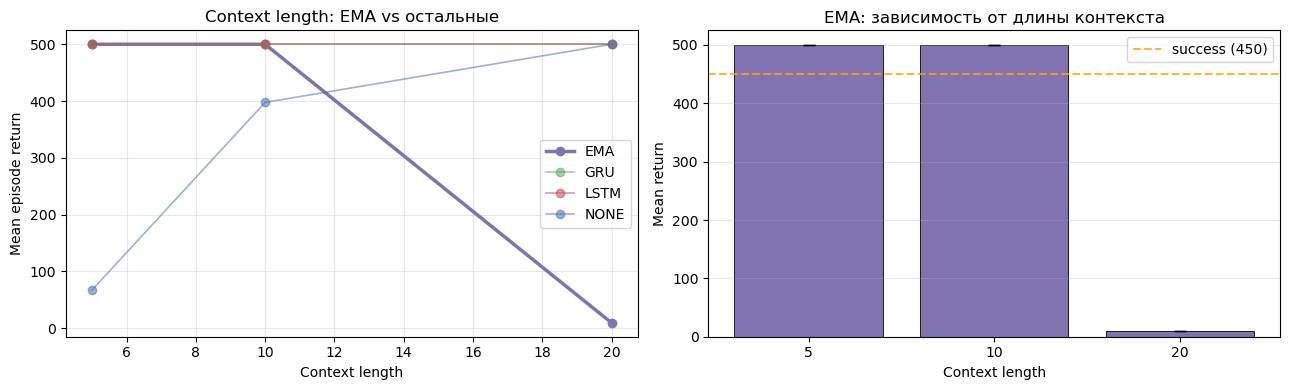

,context_length,mean_return,std_return,success_rate
35,5,500.0,0.000000,1.0
36,10,500.0,0.000000,1.0
37,20,9.6,0.489898,0.0


In [ ]:
# --- EMA: sweep по длине контекста ---
CONTEXT_VALUES = [5, 10, 20]
RUN_EMA_CTX_TRAINING = False  # True — переобучить EMA для каждого context_length

ema_ctx_rows = []
for ctx in CONTEXT_VALUES:
    tag = f"ctx{ctx}"
    ckpt = tagged_checkpoint(CUSTOM_MEMORY, tag)
    trained = False

    if RUN_EMA_CTX_TRAINING or not ckpt.exists():
        print(f"Training EMA, context_length={ctx}...")
        _, mean_r, std_r, sr, ckpt_path, _ = train_and_evaluate(
            memory_type=CUSTOM_MEMORY,
            context_length=ctx,
            experiment_tag=tag,
            target_return=DEFAULT_TARGET_RTG,
        )
        ckpt = Path(ckpt_path)
        trained = True
    else:
        model = load_model_from_checkpoint(ckpt, CUSTOM_MEMORY, ctx)
        mean_r, std_r, sr = run_evaluation(model, ctx, DEFAULT_TARGET_RTG)

    print(f"  EMA ctx={ctx}: return={mean_r:.1f} ± {std_r:.1f}, success={sr:.1%}")
    ema_ctx_rows.append(
        ExperimentResult(
            experiment="ema_context_sweep",
            memory_type=CUSTOM_MEMORY,
            context_length=ctx,
            n_trajectories=None,
            target_return=DEFAULT_TARGET_RTG,
            mean_return=mean_r,
            std_return=std_r,
            success_rate=sr,
            model_path=str(ckpt),
            trained=trained,
        )
    )

df_all = append_results(ema_ctx_rows)
df_ema_ctx = df_all[df_all["experiment"] == "ema_context_sweep"]

df_ctx_base = load_all_results()
df_ctx_base = df_ctx_base[df_ctx_base["experiment"] == "context_sweep"]
df_ctx_overlay = pd.concat([df_ctx_base, df_ema_ctx], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for mem, g in df_ctx_overlay.groupby("memory_type"):
    g = g.sort_values("context_length")
    lw = 2.5 if mem == "ema" else 1.2
    alpha = 1.0 if mem == "ema" else 0.55
    ax.plot(
        g["context_length"],
        g["mean_return"],
        marker="o",
        label=mem.upper(),
        color=COLORS.get(mem),
        linewidth=lw,
        alpha=alpha,
    )
ax.set_xlabel("Context length")
ax.set_ylabel("Mean episode return")
ax.set_title("Context length: EMA vs остальные")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
g = df_ema_ctx.sort_values("context_length")
ax.bar(
    g["context_length"].astype(str),
    g["mean_return"],
    yerr=g["std_return"],
    color=COLORS["ema"],
    capsize=4,
    edgecolor="black",
    linewidth=0.6,
)
ax.set_xlabel("Context length")
ax.set_ylabel("Mean return")
ax.set_title("EMA: зависимость от длины контекста")
ax.axhline(SUCCESS_THRESHOLD, color="orange", ls="--", alpha=0.8, label="success (450)")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "ema_context_comparison.png", dpi=150)
plt.show()

display(df_ema_ctx[["context_length", "mean_return", "std_return", "success_rate"]])

Получилась интересная картина. Из-за того, что ema не переносит память между шагами увеличение context_lenth ухудшает эффект. Однако даже такая эвристика дает неплохой буст в результате, уступающий, правда, LSTM и GRU. Зависимость от RTG напоминает none подход.